# 04. Technology Trends & Adoption

This notebook details technology adoption and shifts in developer tool usage over the years. We analyze:
1. Programming language popularity trends (2021-2025)
2. Database adoption over time
3. Web framework adoption
4. 'Love vs. Dread' (Admired vs. Desired) technology index

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Programming Language Trends (2021-2025)

Let's see which programming languages have grown, declined, or stayed stable.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


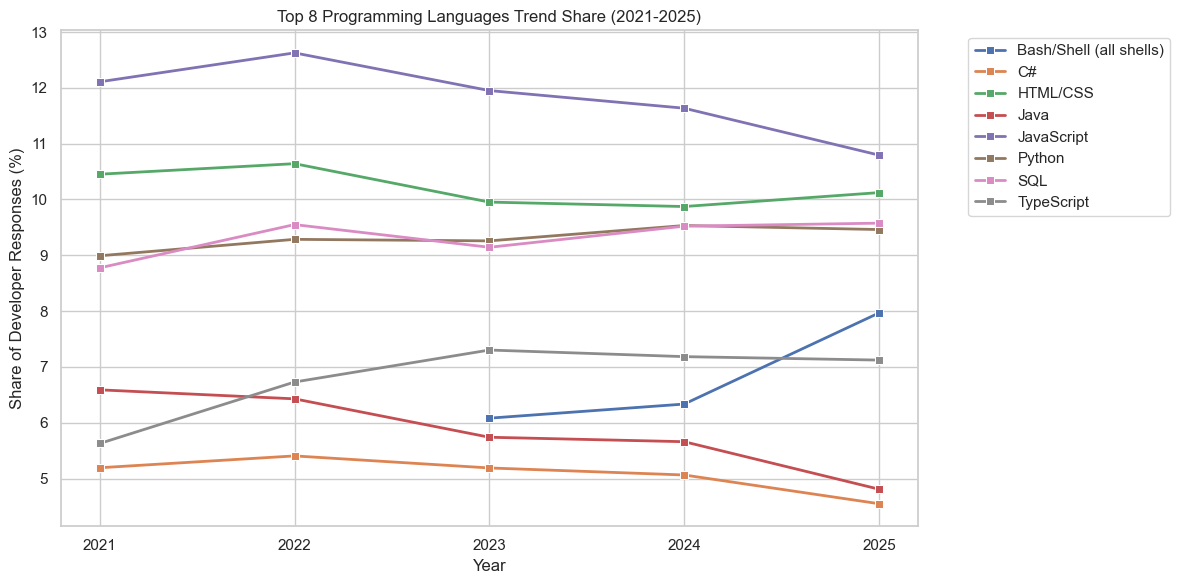

In [2]:
lang_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    lang.LanguageHaveWorkedWith_Clean AS Language,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_LanguageHaveWorkedWith_Clean lang ON f.ResponseKey = lang.ResponseKey
GROUP BY YEAR(f.SurveyYear), lang.LanguageHaveWorkedWith_Clean;
"""
df_lang = db.read_query(lang_query)

if df_lang is not None and not df_lang.empty:
    # Calculate percentage share for each language per year
    year_totals = df_lang.groupby('Year')['Count'].sum().reset_index().rename(columns={'Count': 'TotalCount'})
    df_lang_share = df_lang.merge(year_totals, on='Year')
    df_lang_share['Percentage'] = (df_lang_share['Count'] / df_lang_share['TotalCount']) * 100
    
    # Get top 8 languages in 2025 to track their history
    top_langs_2025 = df_lang[df_lang['Year'] == 2025].nlargest(8, 'Count')['Language'].tolist()
    df_top_langs = df_lang_share[df_lang_share['Language'].isin(top_langs_2025)]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_top_langs, x='Year', y='Percentage', hue='Language', marker='s', linewidth=2)
    plt.title('Top 8 Programming Languages Trend Share (2021-2025)')
    plt.xlabel('Year')
    plt.ylabel('Share of Developer Responses (%)')
    plt.xticks([2021, 2022, 2023, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '04_language_trends.png'), dpi=300)
    plt.show()
else:
    print("No language data available.")

### 2. Database Adoption over Time

Let's check the database management systems most worked with.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


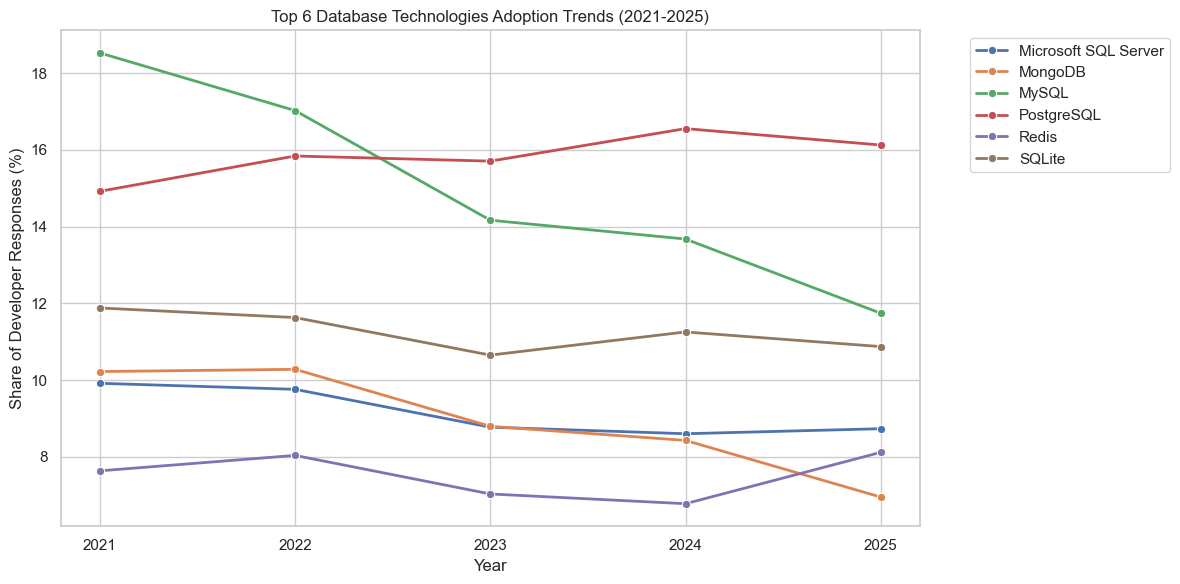

In [3]:
db_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    db_bridge.DatabaseHaveWorkedWith_Clean AS DatabaseName,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_DatabaseHaveWorkedWith_Clean db_bridge ON f.ResponseKey = db_bridge.ResponseKey
GROUP BY YEAR(f.SurveyYear), db_bridge.DatabaseHaveWorkedWith_Clean;
"""
df_db = db.read_query(db_query)

if df_db is not None and not df_db.empty:
    year_db_totals = df_db.groupby('Year')['Count'].sum().reset_index().rename(columns={'Count': 'TotalCount'})
    df_db_share = df_db.merge(year_db_totals, on='Year')
    df_db_share['Percentage'] = (df_db_share['Count'] / df_db_share['TotalCount']) * 100
    
    top_dbs_2025 = df_db[df_db['Year'] == 2025].nlargest(6, 'Count')['DatabaseName'].tolist()
    df_top_dbs = df_db_share[df_db_share['DatabaseName'].isin(top_dbs_2025)]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_top_dbs, x='Year', y='Percentage', hue='DatabaseName', marker='o', linewidth=2)
    plt.title('Top 6 Database Technologies Adoption Trends (2021-2025)')
    plt.xlabel('Year')
    plt.ylabel('Share of Developer Responses (%)')
    plt.xticks([2021, 2022, 2023, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '04_database_trends.png'), dpi=300)
    plt.show()
else:
    print("No database data available.")

### 3. Web Framework Adoption

Let's see the most popular web frameworks and libraries.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


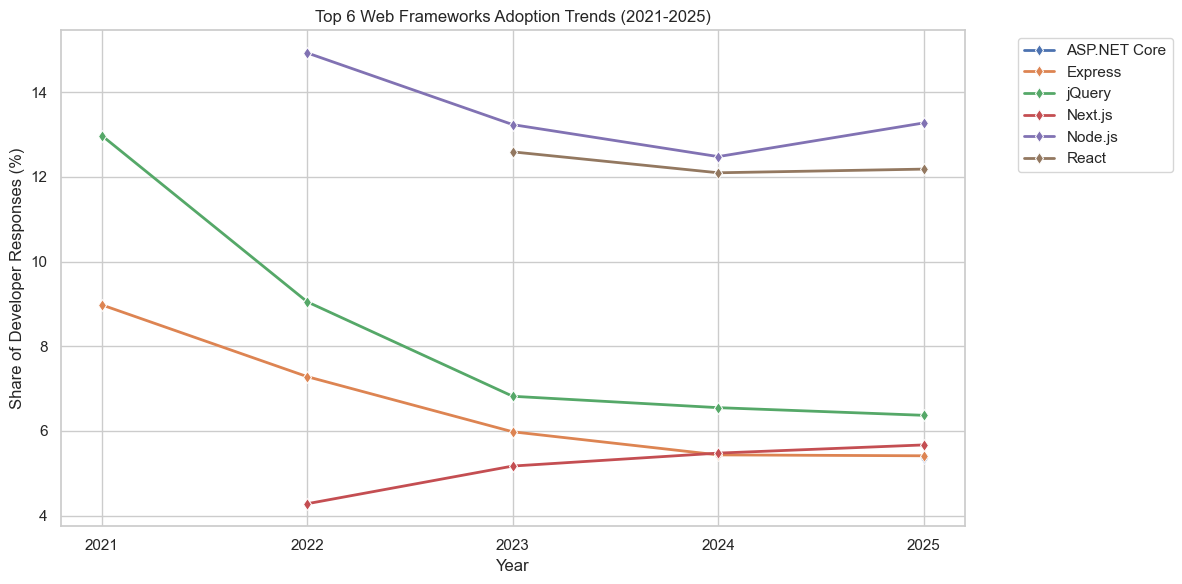

In [4]:
web_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    web.WebframeHaveWorkedWith_Clean AS Webframe,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_WebframeHaveWorkedWith_Clean web ON f.ResponseKey = web.ResponseKey
GROUP BY YEAR(f.SurveyYear), web.WebframeHaveWorkedWith_Clean;
"""
df_web = db.read_query(web_query)

if df_web is not None and not df_web.empty:
    year_web_totals = df_web.groupby('Year')['Count'].sum().reset_index().rename(columns={'Count': 'TotalCount'})
    df_web_share = df_web.merge(year_web_totals, on='Year')
    df_web_share['Percentage'] = (df_web_share['Count'] / df_web_share['TotalCount']) * 100
    
    top_webs_2025 = df_web[df_web['Year'] == 2025].nlargest(6, 'Count')['Webframe'].tolist()
    df_top_webs = df_web_share[df_web_share['Webframe'].isin(top_webs_2025)]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_top_webs, x='Year', y='Percentage', hue='Webframe', marker='d', linewidth=2)
    plt.title('Top 6 Web Frameworks Adoption Trends (2021-2025)')
    plt.xlabel('Year')
    plt.ylabel('Share of Developer Responses (%)')
    plt.xticks([2021, 2022, 2023, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '04_webframe_trends.png'), dpi=300)
    plt.show()
else:
    print("No web framework data available.")

### 4. Love vs. Dread (Admired vs. Desired / Want vs. Have)

We check the ratio of `Want to Work With` vs. `Have Worked With` for programming languages in 2025. Ratios > 1 signify a technology that developers are eager to adopt compared to its current usage.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully
Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_22744\1690975220.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ratio_top, x='Desirability_Ratio', y='Language', palette='flare')


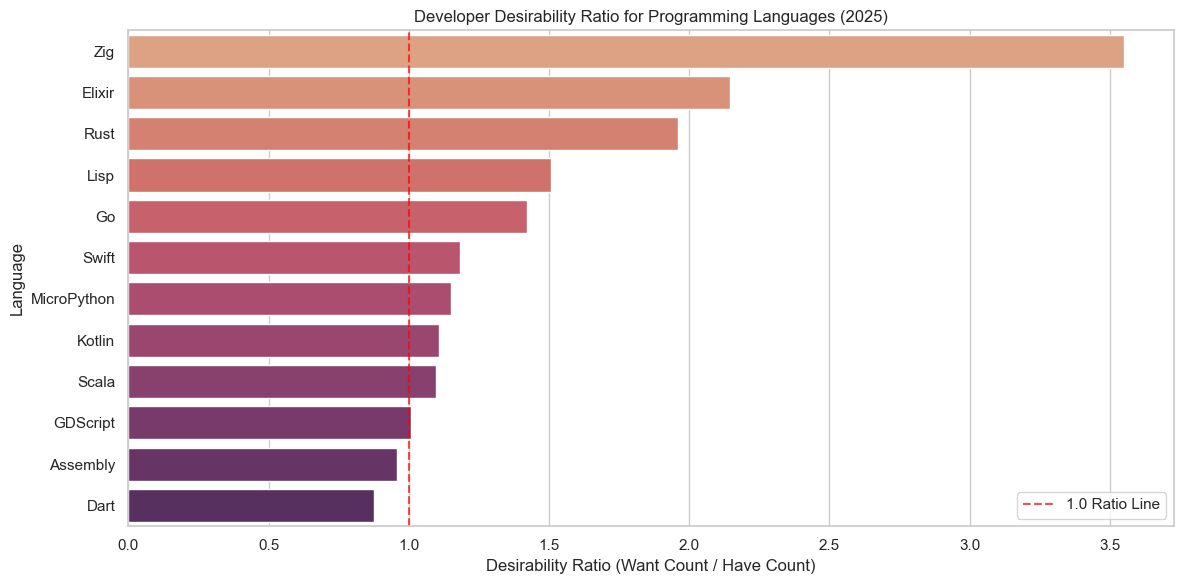

In [5]:
have_lang_query = """
SELECT 
    lang.LanguageHaveWorkedWith_Clean AS Language,
    COUNT(DISTINCT f.ResponseKey) AS HaveCount
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_LanguageHaveWorkedWith_Clean lang ON f.ResponseKey = lang.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025
GROUP BY lang.LanguageHaveWorkedWith_Clean;
"""
want_lang_query = """
SELECT 
    lang.LanguageWantToWorkWith_Clean AS Language,
    COUNT(DISTINCT f.ResponseKey) AS WantCount
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_LanguageWantToWorkWith_Clean lang ON f.ResponseKey = lang.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025
GROUP BY lang.LanguageWantToWorkWith_Clean;
"""
df_have = db.read_query(have_lang_query)
df_want = db.read_query(want_lang_query)

if df_have is not None and df_want is not None:
    df_ratio = df_have.merge(df_want, on='Language')
    # Filter to languages with at least 500 users to avoid tiny sample volatility
    df_ratio = df_ratio[df_ratio['HaveCount'] > 500]
    df_ratio['Desirability_Ratio'] = df_ratio['WantCount'] / df_ratio['HaveCount']
    
    # Sort and plot top 12
    df_ratio_top = df_ratio.sort_values(by='Desirability_Ratio', ascending=False).head(12)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_ratio_top, x='Desirability_Ratio', y='Language', palette='flare')
    plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='1.0 Ratio Line')
    plt.title('Developer Desirability Ratio for Programming Languages (2025)')
    plt.xlabel('Desirability Ratio (Want Count / Have Count)')
    plt.ylabel('Language')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '04_language_desirability.png'), dpi=300)
    plt.show()
else:
    print("Failed to load have/want data.")

In [6]:
db.close()

Connection closed.
